# Lab 2: CNN Interpretability with LayerCAM

## Introduction

In this lab, I investigate interprebailty in a convolutional neural network using class activations maps. The goal of this laboration is to understand which part of an image the model focuses on while making predictions. In this case,the pretrained Resnet18 model trained on Imagenet was used. I test three images, a white labrador, a pizza and a sports car.

For each image I generate a heatmap using LayerCAM and analyze what part of the image regions the model focuses on.

## Imports

In [16]:
import torch
import matplotlib.pyplot as plt

from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchvision.transforms.v2.functional import to_pil_image

from torchcam.methods import LayerCAM
from torchcam.utils import overlay_mask

## Model

The model used in this lab is ResNet18.
ResNet is a neural network trained on ImageNet, which contains 1000 images classes. Since the model is pretraine, it already know how to recognize many common objects such as animals, food and veichles.

To vizualize the predcition LayerCAM is used. LayerCAM creates a heatmap that highlight the most important parts of the prediction.

In [17]:
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

In [18]:
def run_cam(img_path, title):

    img = decode_image(img_path)
    input_tensor = preprocess(img)

    with LayerCAM(model) as cam_extractor:

        out = model(input_tensor.unsqueeze(0))

        activation_map = cam_extractor(
            out.squeeze(0).argmax().item(),
            out
        )

    result = overlay_mask(
        to_pil_image(img),
        to_pil_image(activation_map[0].squeeze(0), mode='F'),
        alpha=0.5
    )

    plt.figure(figsize=(6,6))
    plt.imshow(result)
    plt.title(title)
    plt.axis("off")
    plt.show()

## White Labrador

The first image is a white labrador retriever.

This image is used as 
- A positive example for the labrador class
- A negative example for the pizza and sports car class

The purpose is to see wether the model focuses on the dog itself while making predictions.

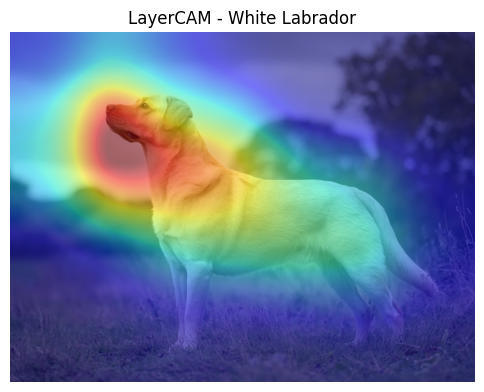

In [19]:
run_cam(
    "/Users/wilgotlucaci/Desktop/white-lab.webp",
    "LayerCAM - White Labrador"
)

## Analysis

The heatmap mainly highlights the dogs neck and face area. This shows that the model focuses on the dog itself and not the background. Theese highlighted areas are important because they correspond to important features such as fur, head shape and body outline of a labrador.

The model classified the image correctly with a high confidence

## Pizza

The second image is a pizza.

This image acts as:

- a positive example for the pizza class
- a negative example for Labrador and sports car

The goal is to examine whether the model focuses on the pizza itself rather than unrelated background objects.

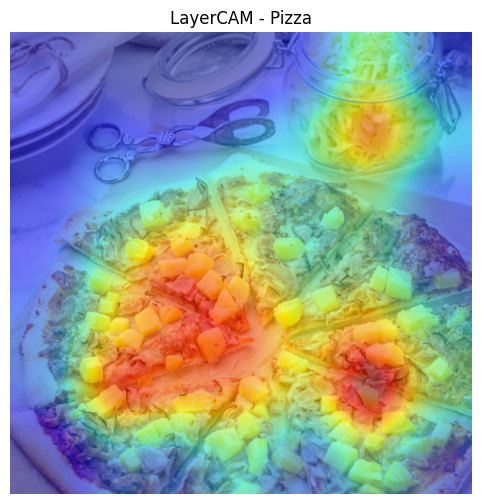

In [20]:
run_cam(
    "/Users/wilgotlucaci/Desktop/pizza.jpg",
    "LayerCAM - Pizza"
)

## Analysis

The layerCAM heatmap maninly highlights the toppings and the center of the pizza slices. The red and yellow ares represent regions that contributed strongly to the prediction, while blue and purple areas had less of an influence.

The model appears to focus on visual features such as:
- Pizza toppings
- Triangluar shape of a slice
- Circular pizza shape

Very litte attention is given to the surroudning background meaning that the model is using relevent image features when classyfying the pizza.

# Sports Car

The final image contains a sports car.

This image is:
- a positive example for the sports car class
- a negative example for Labrador and pizza

The purpose is to see whether the model focuses on vehicle-related features.

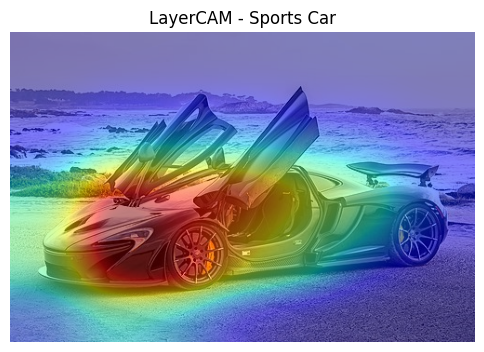

In [21]:
run_cam(
    "/Users/wilgotlucaci/Desktop/sportcar.jpg",
    "LayerCAM - Sports Car"
)

## Analysis

The LayerCAM heatmap mainly focuses on the front section of the car. This includes the hood, wheel area and the aerodynamic structure of the frontend.

This suggest that the model uses charectristics veichle features when making its prediction. Sports cars often have:
- Low body height
- Large rims
- aerodynamic curves

The strongest activations apear in theese regions indicating that the nueral network considers them important for the classification.

Very little attention is given to background of the image, this suggest that the predciton is primarily based on the veichle itself.

## Discussion

The LayerCAM visualizations help explain how the neural network makes decisions.

Instead of only showing a predicted class, the heatmaps reveal which image regions contributed most strongly to the prediction.

For all three images, the highlighted areas corresponded to the main object in the image:

- The Labrador

- The pizza

- The sports car

This indicates that the model focuses on relevant visual information.

However, CAM methods also have limitations. The heatmaps do not fully explain how the model reasons internally. They only show which image regions were important for a specific prediction.

## Conclussion

In this lab, I used LayerCAM together with a pretrained ResNET18 model to investigate the CNN interprebailty.
The heatmaps showed that the model focused on meaingful areas of the images in order to classify the objects with a high confidnce. 
The laboration shows how attribution models such as LayerCAM can improve the transparency in deep learing models.